# LALSimulation TD example

In [1]:
%pylab inline
%config InlineBackend.figure_format = 'retina'

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import os
# you must set LAL_DATA_PATH if you wish to use NRSur
os.environ["LAL_DATA_PATH"] = os.path.join(os.environ['HOME'], "lscsoft/src/lalsuite-extra/data/lalsimulation/")

import lalsimulation as lalsim
import lal

import seaborn as sns
sns.set_theme(palette='colorblind', font_scale=1.2)

## Get a time-domain waveform

In [8]:
approximant = lalsim.SimInspiralGetApproximantFromString("NRSur7dq4")

# time array parameters
delta_t = 1/4096.
f_min = 20.
f_ref = f_min

# source parameters
m1_msun = 30
m2_msun = 30
chi1 = [0, 0, 0.5]
chi2 = [0, 0, 0.5]
dist_mpc = 440
inclination = 0
phi_ref = 0

m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

hp, hc = lalsim.SimInspiralChooseTDWaveform(m1_kg, m2_kg,
                                            chi1[0], chi1[1], chi1[2],
                                            chi2[0], chi2[1], chi2[2],
                                            distance, inclination,
                                            phi_ref, 0, 0., 0.,
                                            delta_t, f_min, f_ref,
                                            None, approximant)

Plot the time-domain polarizations:

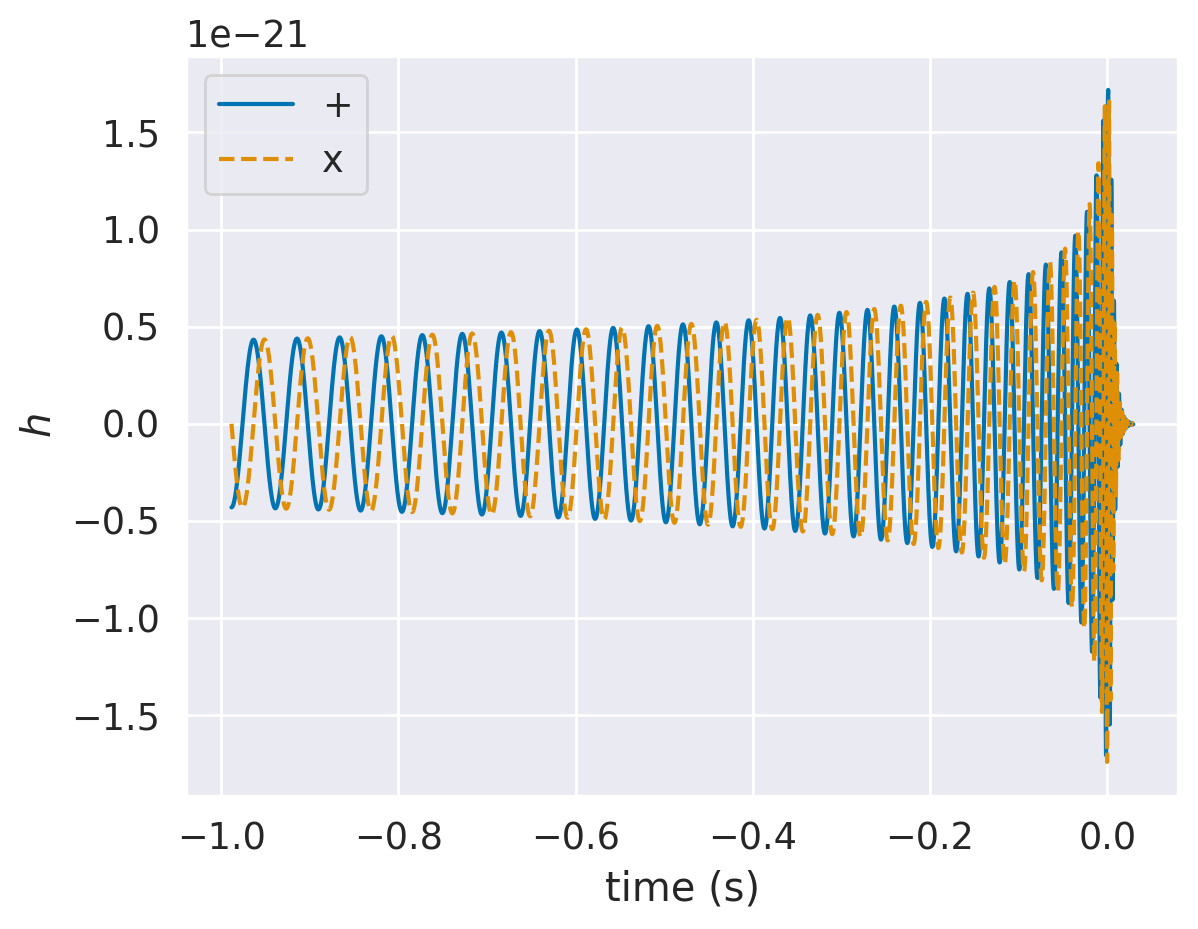

In [53]:
time = arange(len(hp.data.data))*hp.deltaT + float(hp.epoch)
plot(time, hp.data.data, label="+")
plot(time, hc.data.data, ls='--', label="x") 
legend()
xlabel("time (s)")
ylabel(r"$h$");

Let's insert this waveform in a longer time segment, as would correspond to an analysis segment in `LALInference`. For FFTing below, we will use a sharp Tukey window (I have picked `alpha=0.06` but you should always check what is appropriate---e.g., LALInference will place a Tukey window with `alpha=0.1` over a 4s segment for a BBH)

In [26]:
from scipy.signal import tukey

In [118]:
n = int(4./delta_t)
time_long = arange(n)*delta_t + time[0] - int(1/delta_t)*delta_t

hp_long = zeros_like(time_long)
hp_long[(time_long >= time[0]) & (time_long <= time[-1])] = hp.data.data*tukey(len(time), alpha=0.06)

hc_long = zeros_like(time_long)
hc_long[(time_long >= time[0]) & (time_long <= time[-1])] = hc.data.data*tukey(len(time), alpha=0.06)

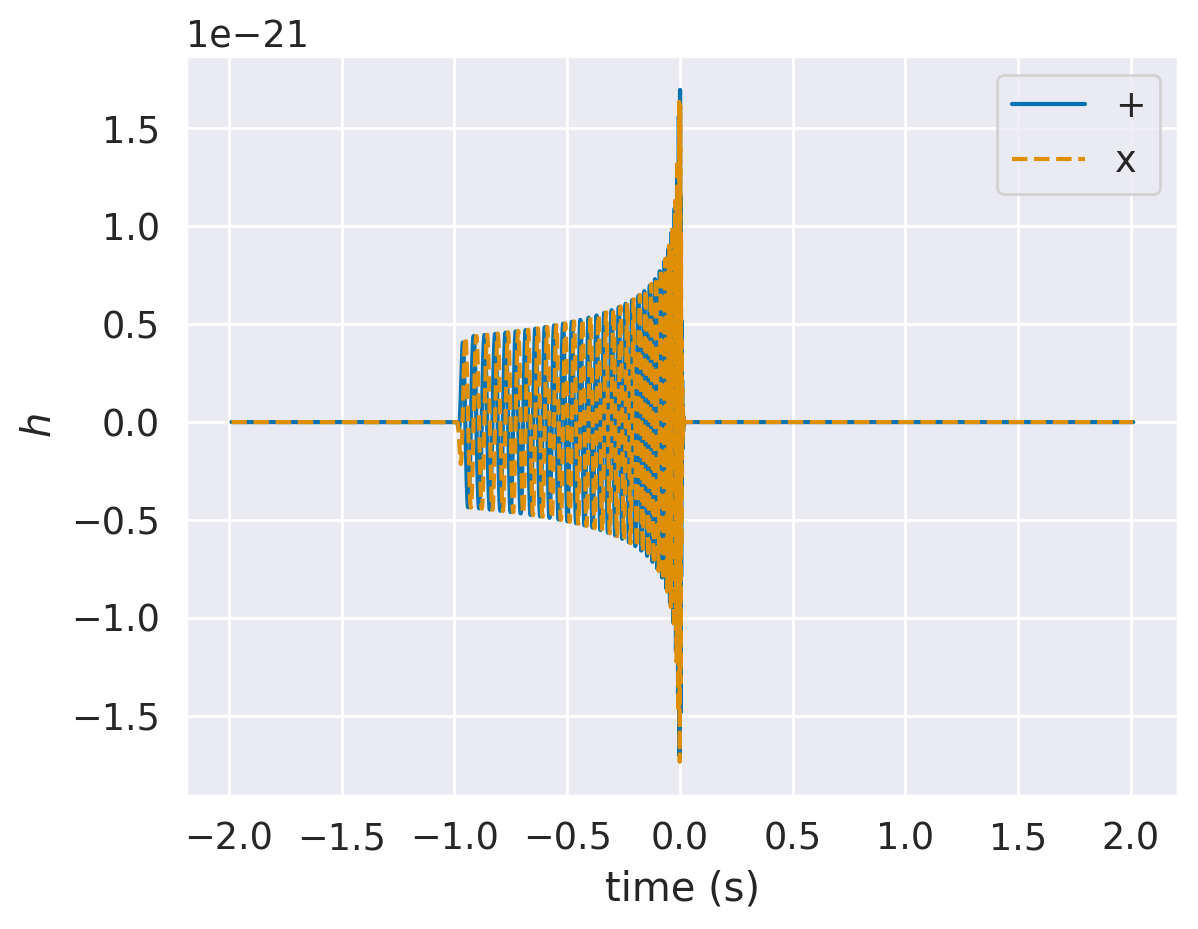

In [119]:
plot(time_long, hp_long, label="+")
plot(time_long, hc_long, ls='--', label="x") 
legend()
xlabel("time (s)")
ylabel(r"$h$");

Fourier transform and plot. .

In [120]:
hp_fd = np.fft.rfft(hp_long) * delta_t
hc_fd = np.fft.rfft(hc_long) * delta_t
freq = np.fft.rfftfreq(n, d=delta_t)

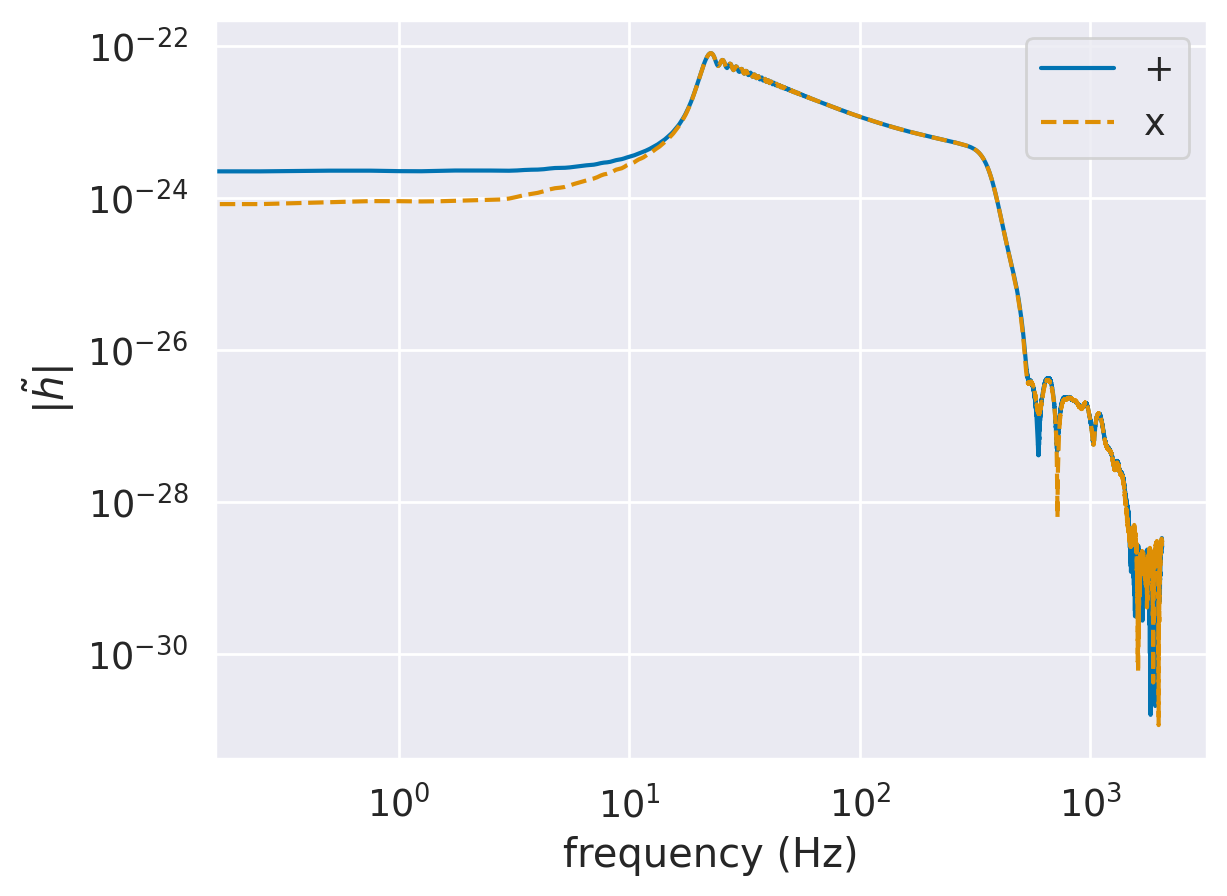

In [121]:
loglog(freq, abs(hp_fd), label="+")
loglog(freq, abs(hc_fd), ls='--', label="x")
legend()
xlabel("frequency (Hz)")
ylabel(r"$|\tilde{h}|$");

Plot the Fourier phase:

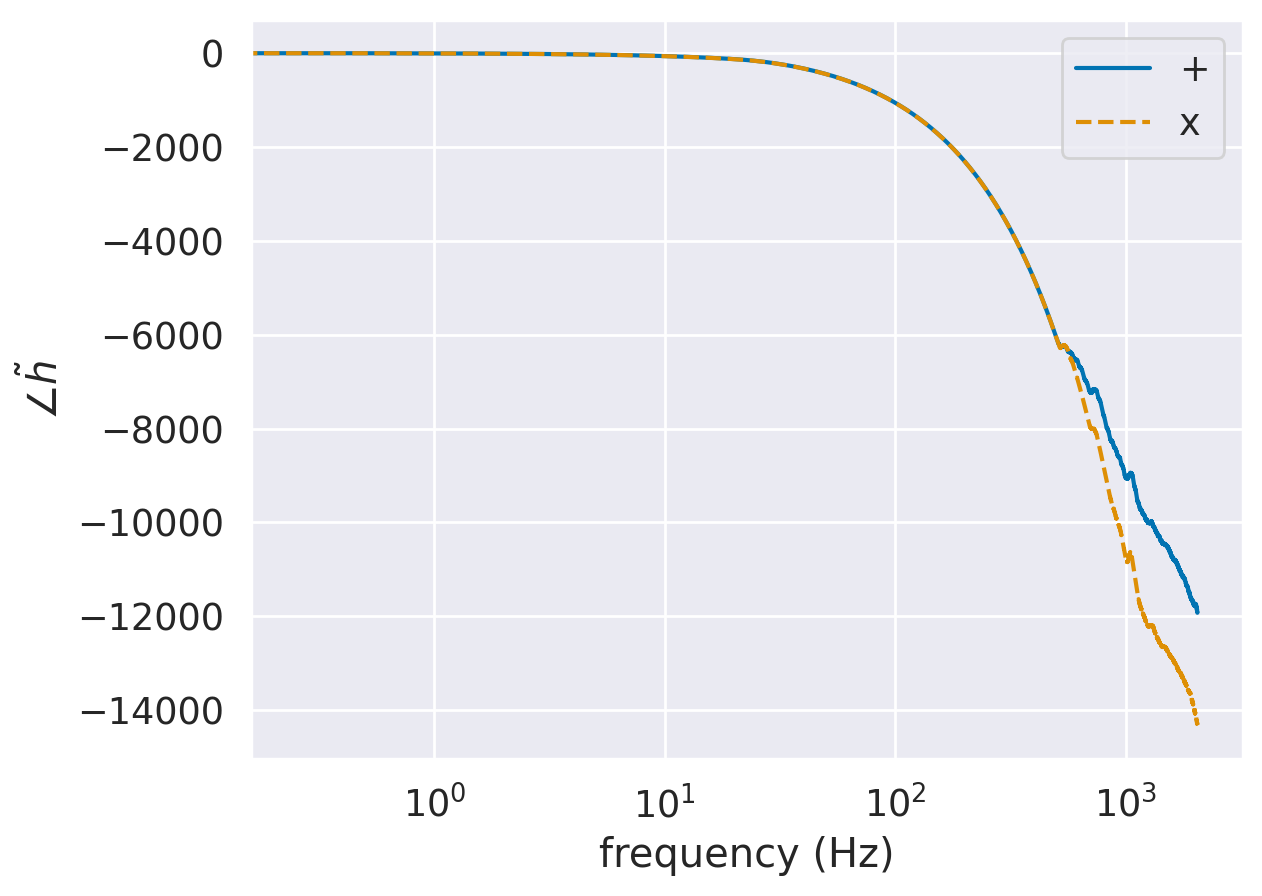

In [123]:
semilogx(freq, unwrap(angle(hp_fd)), label="+")
semilogx(freq, unwrap(angle(hc_fd)), ls='--', label="x")
legend()
xlabel("frequency (Hz)")
ylabel(r"$\angle \tilde{h}$");

### Detector projection

Getting antenna patterns and projecting onto a detector, accounting for time delays from geocenter. For that, we must assume some arrival time at geocenter and a sky location.

In [124]:
t_geocenter = 1126259462.4083147
ra = 1.95
dec = -1.27
psi = 0.82

In [125]:
# get antenna patterns and time delay for LIGO Hanford
det = lal.cached_detector_by_prefix['H1']
gmst = lal.GreenwichMeanSiderealTime(t_geocenter)
Fp, Fc = lal.ComputeDetAMResponse(det.response, ra, dec, psi, gmst)
dt = lal.TimeDelayFromEarthCenter(det.location, ra, dec, t_geocenter)

Now create the time series as would be measured by the detector:

In [126]:
h_fd = (Fp*hp_fd + Fc*hc_fd)*np.exp(2j*pi*freq*dt)

Inverse Fourier transform back to the time domain.

In [129]:
h_td = np.fft.irfft(h_fd) / delta_t

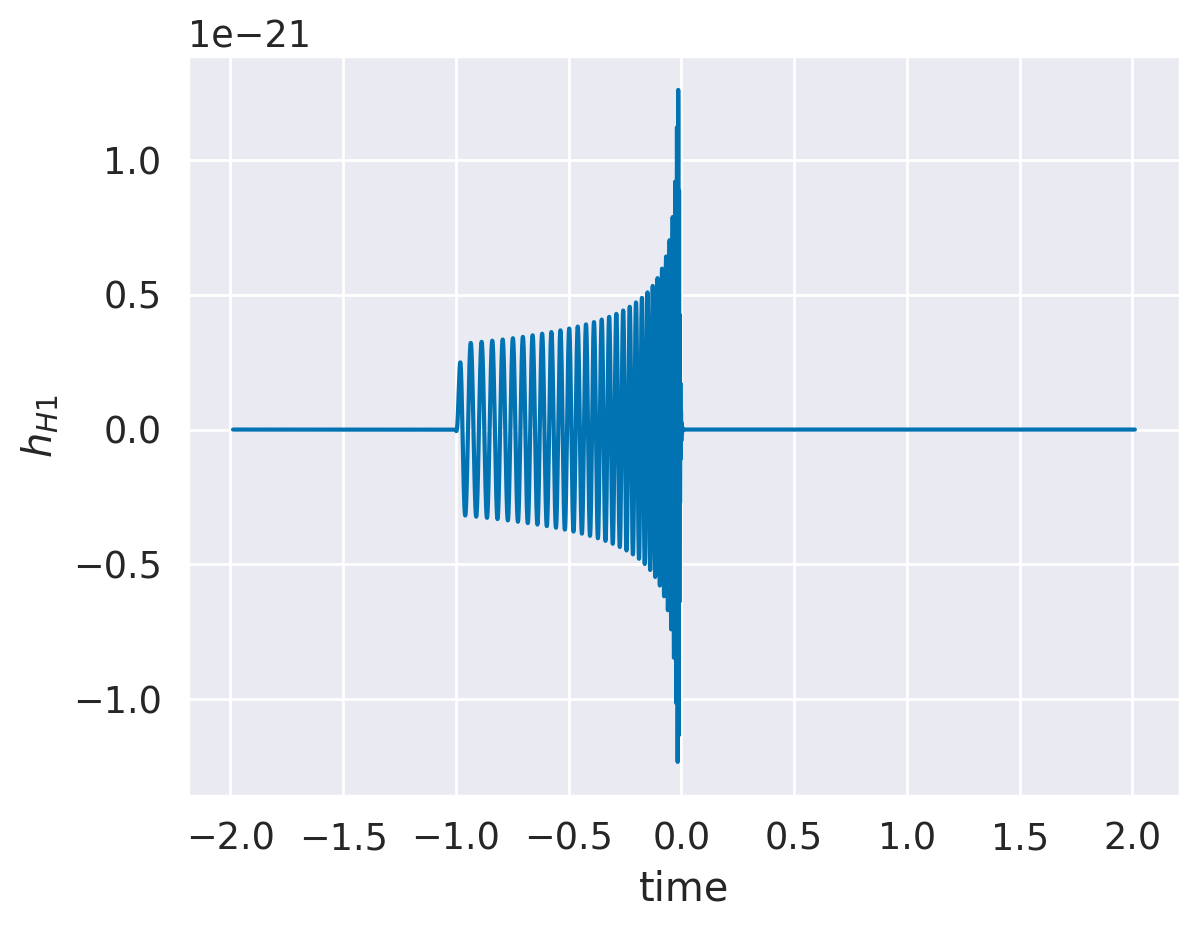

In [131]:
plot(time_long, h_td)
xlabel("time")
ylabel(r"$h_{H1}$");

Note that we have only shifted the waveform by a tiny `dt` corresponding to the time-of-flight from geocenter; in a regular use case, we would have first shifted to the geocenter GPS time in order to align the waveform with the data properly.